In [1]:
import numpy as np
import astropy.units as u
import astropy.constants as const
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation
import spiceypy as spice

from light_deflection import delta_kpn, calc_kP
from ephemeris import ephem_kernel, on_sky_velocity

from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d

In [2]:
# Occultation parameters
occ_time = Time('2021-04-02 10:24:00', scale='utc')
occ_vel = 16.54*u.km/u.s
io_radius = 1821*u.km

In [3]:
# Geocentric star position at occultation epoch
# propagated with proper motion, parallax and radial velocity using Butkevich & Lindegren (2014)
pos_star = SkyCoord('21h43m04.38939019s -14d23m58.5335448s', distance=142.9253799674684*u.pc)

In [4]:
# GM of Jupiter and Sun form JUP365: https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/satellites/jup365.cmt
jup_GM = 1.266865319003704E+08 * (u.km**3) / (u.s**2)
sun_GM = 1.327132332633514E+11 * (u.km**3) / (u.s**2)
# Jupiter and Io SPKID
jup_spkid = '599'
sun_spkid = '10'
io_spkid = '501'

In [5]:
lons = np.linspace(-52,-7, 501)*u.deg
lats = np.linspace(-21, 25, 501)*u.deg
shape = (len(lons), len(lats))

In [6]:
obs = EarthLocation(lon=lons[:,np.newaxis], lat=lats[np.newaxis,:], height=0*u.km)

In [7]:
# JUP365 in local server
kernel = ['/srv/jupyterhub/shared/data/kernels/jup365.bsp']
spice.furnsh(kernel)

In [8]:
t0 = Time('J2000', scale='tdb')
dt = (occ_time - t0)

# calculates vector Solar System Barycenter -> Geocenter
state = spice.spkpos('399', dt.sec, 'J2000', 'NONE', '0')[0]
barycenter_geocenter = SkyCoord(*state.T * u.km, representation_type='cartesian').cartesian

In [9]:
# vector Solar System Barycenter -> Topocenter
geocenter_observer = obs.get_gcrs(obstime=occ_time).cartesian
barycenter_observer = barycenter_geocenter + geocenter_observer

In [10]:
def pos_object(target):
    delt = 0 * u.s
    while True:
        # calculates new time
        tempo = dt - delt
        # calculates vector Solar System Barycenter -> Target
        barycenter_object = spice.spkpos(target, tempo.sec, 'J2000', 'NONE', '0')[0]
        barycenter_object = SkyCoord(*barycenter_object.T * u.km, representation_type='cartesian').cartesian
        # calculates vector Observer -> Target considering light time
        observer_object = barycenter_object - barycenter_observer
        # calculates new light time
        delt = (observer_object.norm() / const.c).decompose()
        # if difference between new and previous light time is smaller than 0.001 sec, then continue.
        if np.all(np.absolute(((dt - tempo) - delt).sec) < 0.001):
            return observer_object

In [11]:
# x_jup, y_jup, z_jup = np.zeros(shape), np.zeros(shape), np.zeros(shape)
# x_sun, y_sun, z_sun = np.zeros(shape), np.zeros(shape), np.zeros(shape)
# x_io, y_io, z_io = np.zeros(shape), np.zeros(shape), np.zeros(shape)
# for i, lon in tqdm(enumerate(lons), total=len(lons)):
#     for j, lat in enumerate(lats):
#         pos_jup = pos_object(jup_spkid, barycenter_observer[i,j])
#         x_jup[i,j], y_jup[i,j], z_jup[i,j] = pos_jup.xyz.to(u.km).value
#         pos_sun = pos_object(sun_spkid, barycenter_observer[i,j])
#         x_sun[i,j], y_sun[i,j], z_sun[i,j] = pos_sun.xyz.to(u.km).value
#         pos_io = pos_object(io_spkid, barycenter_observer[i,j])
#         x_io[i,j], y_io[i,j], z_io[i,j] = pos_io.xyz.to(u.km).value

# spice.kclear()

100%|██████████| 501/501 [25:40<00:00,  3.08s/it]


In [11]:
pos_jup = pos_object(jup_spkid)
pos_sun = pos_object(sun_spkid)
pos_io = pos_object(io_spkid)

spice.kclear()

100%|██████████| 501/501 [25:40<00:00,  3.08s/it]


In [12]:
# pos_jup = SkyCoord(x_jup, y_jup, z_jup, unit='km', representation_type='cartesian')
# pos_sun = SkyCoord(x_sun, y_sun, z_sun, unit='km', representation_type='cartesian')
# pos_io = SkyCoord(x_io, y_io, z_io, unit='km', representation_type='cartesian')

In [13]:
DE_io = pos_io.cartesian.norm()   # target

f = DE_io*(pos_star.ra - pos_io.spherical.lon)*np.cos(pos_io.spherical.lat)
g = DE_io*(pos_star.dec - pos_io.spherical.lat)
f = f.to(u.km, equivalencies=u.dimensionless_angles())
g = g.to(u.km, equivalencies=u.dimensionless_angles())

vec_rso = - pos_star.cartesian
vec_rao = - pos_jup.cartesian
vec_ras = pos_star.cartesian - pos_jup.cartesian
delta_k_star_jup = delta_kpn(gm=jup_GM, vec_rso=vec_rso, vec_rao=vec_rao, vec_ras=vec_ras)

vec_rso = - pos_star.cartesian
vec_rao = - pos_sun.cartesian
vec_ras = pos_star.cartesian - pos_sun.cartesian
delta_k_star_sun = delta_kpn(gm=sun_GM, vec_rso=vec_rso, vec_rao=vec_rao, vec_ras=vec_ras)

vec_rso = - pos_io.cartesian
vec_rao = - pos_jup.cartesian
vec_ras = pos_io.cartesian - pos_jup.cartesian
delta_k_E_jup = delta_kpn(gm=jup_GM, vec_rso=vec_rso, vec_rao=vec_rao, vec_ras=vec_ras)

vec_rso = - pos_io.cartesian
vec_rao = - pos_sun.cartesian
vec_ras = pos_io.cartesian - pos_sun.cartesian
delta_k_E_sun = delta_kpn(gm=sun_GM, vec_rso=vec_rso, vec_rao=vec_rao, vec_ras=vec_ras)

delta_theta_jup, theta_f_jup, theta_g_jup = calc_kP(gm=jup_GM, pos_A=pos_jup, pos_E=pos_io, delta_k_star = delta_k_star_jup)
delta_theta_sun, theta_f_sun, theta_g_sun = calc_kP(gm=sun_GM, pos_A=pos_sun, pos_E=pos_io, delta_k_star = delta_k_star_sun)

delta_f = DE_io*(theta_f_jup + theta_f_sun)
delta_g = DE_io*(theta_g_jup + theta_g_sun)

delta_f_jup = (DE_io*theta_f_jup).to(u.km, equivalencies=u.dimensionless_angles())
delta_g_jup = (DE_io*theta_g_jup).to(u.km, equivalencies=u.dimensionless_angles())
delta_f_sun = (DE_io*theta_f_sun).to(u.km, equivalencies=u.dimensionless_angles())
delta_g_sun = (DE_io*theta_g_sun).to(u.km, equivalencies=u.dimensionless_angles())

delta_f_P = delta_f.to(u.km, equivalencies=u.dimensionless_angles())
delta_g_P = delta_g.to(u.km, equivalencies=u.dimensionless_angles())

delta_theta_E = (delta_k_star_jup + delta_k_star_sun) - (delta_k_E_jup + delta_k_E_sun)

e_f = SkyCoord(-np.sin(pos_io.spherical.lon), np.cos(pos_io.spherical.lon), 0, representation_type='cartesian')
e_g = SkyCoord(-np.cos(pos_io.spherical.lon)*np.sin(pos_io.spherical.lat),
               -np.sin(pos_io.spherical.lon)*np.sin(pos_io.spherical.lat),
               np.cos(pos_io.spherical.lat), representation_type='cartesian')

delta_f_E = (DE_io*np.sum(delta_theta_E.xyz*e_f.cartesian.xyz, axis=0)).to(u.km)
delta_g_E = (DE_io*np.sum(delta_theta_E.xyz*e_g.cartesian.xyz, axis=0)).to(u.km)

(-3000.0, 3000.0)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


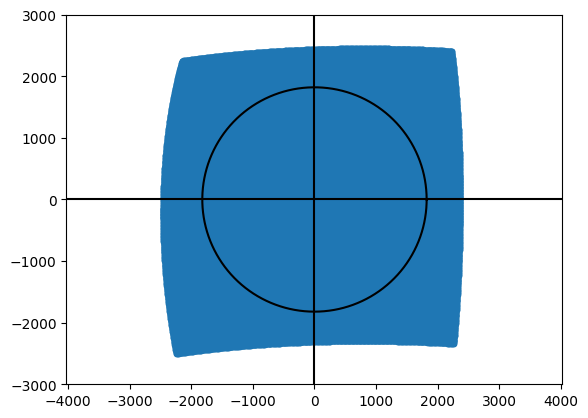

In [14]:
plt.scatter(f, g, marker='.')
plt.axhline(0.0, color='black')
plt.axvline(0.0, color='black')
ang = np.linspace(0,360,1000)*np.pi/180
plt.plot(io_radius*np.cos(ang), io_radius*np.sin(ang), color='black')
plt.axis('equal')
plt.xlim(-3000,3000)
plt.ylim(-3000,3000)

In [61]:
chord_dist = np.sqrt(f**2+g**2)
v = np.unravel_index(chord_dist.argmin(), chord_dist.shape)

dif_rel_f = delta_f_P - delta_f_P[v]
dif_rel_g = delta_g_P - delta_g_P[v]
#dif_rel_f = delta_f_P
#dif_rel_g = delta_g_P

In [62]:
obs_center = obs[v]
print(obs_center.lon.deg, obs_center.lat)

-28.420000000000016 0d04m04.8s


In [67]:
plt.rcParams['font.size'] = 12

In [68]:
nx = 40
ny = 40

dx_mean, xedges, yedges, _ = binned_statistic_2d(
    f.flatten(), g.flatten(), dif_rel_f.flatten(),
    statistic='mean',
    bins=[nx, ny]
)

dy_mean, _, _, _ = binned_statistic_2d(
    f.flatten(), g.flatten(), dif_rel_g.flatten(),
    statistic='mean',
    bins=[xedges, yedges]
)

count, _, _, _ = binned_statistic_2d(
    f.flatten(), g.flatten(), dif_rel_f.flatten(),
    statistic='count',
    bins=[xedges, yedges]
)

xc = 0.5 * (xedges[:-1] + xedges[1:])
yc = 0.5 * (yedges[:-1] + yedges[1:])
Xc, Yc = np.meshgrid(xc, yc, indexing='ij')

mask = count > 0

mag = np.sqrt(dx_mean**2 + dy_mean**2)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


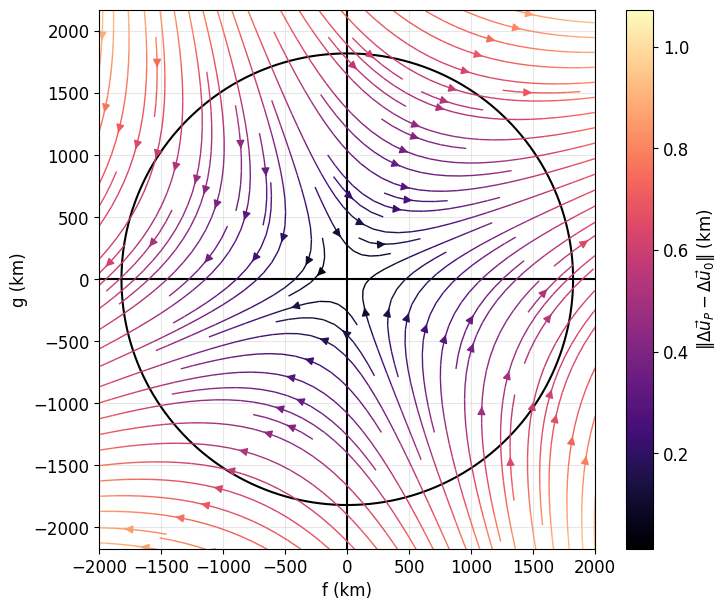

In [70]:
# Atenção: com indexing='xy', os arrays precisam ser transpostos
U = dx_mean.T
V = dy_mean.T
N = count.T

magnitude = np.sqrt(U**2 + V**2)
mask_empty = N == 0

# células vazias devem ser mascaradas
U_masked = np.ma.masked_where(mask_empty, U)
V_masked = np.ma.masked_where(mask_empty, V)
magnitude_masked = np.ma.masked_where(mask_empty, magnitude)

speed = np.sqrt(U_masked**2 + V_masked**2)

fig, ax = plt.subplots(figsize=(8, 7))

plt.axhline(0.0, color='black')
plt.axvline(0.0, color='black')
ang = np.linspace(0,360,1000)*np.pi/180
plt.plot(io_radius*np.cos(ang),io_radius*np.sin(ang), color='black')

# Curvas de nível preenchidas
levels = 20

# # Linhas das curvas de nível
# contour_lines = ax.contour(
#     xc,
#     yc,
#     magnitude_masked,
#     levels=levels,
#     linewidths=0.6
# )

# # Valores escritos sobre algumas curvas
# ax.clabel(
#     contour_lines,
#     inline=True,
#     fontsize=8,
#     fmt='%.2f'
# )

plt.streamplot(
    xc, yc,
    U, V,
    density=1.5,
    color=speed,
    linewidth=1.0,
    arrowsize=1.2,
    cmap='magma'
)

plt.colorbar(label=r'$\|\Delta\vec{u}_P(O,t_0)-\Delta\vec{u}_{0}\|$ (km)')

plt.axis('equal')
plt.xlim(-2000,2000)
plt.ylim(-2000,2000)
plt.xlabel('f (km)')
plt.ylabel('g (km)')
plt.grid(alpha=0.3)
plt.savefig('Residual_deflection.png', dpi=300, bbox_inches='tight')
plt.show()

In [71]:
chord_dist = np.sqrt(f**2+g**2)
v = np.unravel_index(chord_dist.argmin(), chord_dist.shape)

In [72]:
nx = 40
ny = 40

dif_rel_f = delta_f_P
dif_rel_g = delta_g_P
dx_mean, xedges, yedges, _ = binned_statistic_2d(
    f.flatten(), g.flatten(), dif_rel_f.flatten(),
    statistic='mean',
    bins=[nx, ny]
)

dy_mean, _, _, _ = binned_statistic_2d(
    f.flatten(), g.flatten(), dif_rel_g.flatten(),
    statistic='mean',
    bins=[xedges, yedges]
)

count, _, _, _ = binned_statistic_2d(
    f.flatten(), g.flatten(), dif_rel_f.flatten(),
    statistic='count',
    bins=[xedges, yedges]
)

xc = 0.5 * (xedges[:-1] + xedges[1:])
yc = 0.5 * (yedges[:-1] + yedges[1:])
Xc, Yc = np.meshgrid(xc, yc, indexing='ij')

mask = count > 0

mag = np.sqrt(dx_mean**2 + dy_mean**2)

In [73]:
nx = 40
ny = 40

dif_rel_f_jup = delta_f_jup
dif_rel_g_jup = delta_g_jup
dx_mean_jup, xedges_jup, yedges_jup, _ = binned_statistic_2d(
    f.flatten(), g.flatten(), dif_rel_f_jup.flatten(),
    statistic='mean',
    bins=[nx, ny]
)

dy_mean_jup, _, _, _ = binned_statistic_2d(
    f.flatten(), g.flatten(), dif_rel_g_jup.flatten(),
    statistic='mean',
    bins=[xedges_jup, yedges_jup]
)

count_jup, _, _, _ = binned_statistic_2d(
    f.flatten(), g.flatten(), dif_rel_f_jup.flatten(),
    statistic='count',
    bins=[xedges_jup, yedges_jup]
)

xc_jup = 0.5 * (xedges_jup[:-1] + xedges_jup[1:])
yc_jup = 0.5 * (yedges_jup[:-1] + yedges_jup[1:])
Xc_jup, Yc_jup = np.meshgrid(xc_jup, yc_jup, indexing='ij')

mask_jup = count_jup > 0

mag_jup = np.sqrt(dx_mean_jup**2 + dy_mean_jup**2)

In [74]:
nx = 40
ny = 40

dif_rel_f_sun = delta_f_sun
dif_rel_g_sun = delta_g_sun
dx_mean_sun, xedges_sun, yedges_sun, _ = binned_statistic_2d(
    f.flatten(), g.flatten(), dif_rel_f_sun.flatten(),
    statistic='mean',
    bins=[nx, ny]
)

dy_mean_sun, _, _, _ = binned_statistic_2d(
    f.flatten(), g.flatten(), dif_rel_g_sun.flatten(),
    statistic='mean',
    bins=[xedges_sun, yedges_sun]
)

count_sun, _, _, _ = binned_statistic_2d(
    f.flatten(), g.flatten(), dif_rel_f_sun.flatten(),
    statistic='count',
    bins=[xedges_sun, yedges_sun]
)

xc_sun = 0.5 * (xedges_sun[:-1] + xedges_sun[1:])
yc_sun = 0.5 * (yedges_sun[:-1] + yedges_sun[1:])
Xc_sun, Yc_sun = np.meshgrid(xc_sun, yc_sun, indexing='ij')

mask_sun = count_sun > 0

mag_sun = np.sqrt(dx_mean_sun**2 + dy_mean_sun**2)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


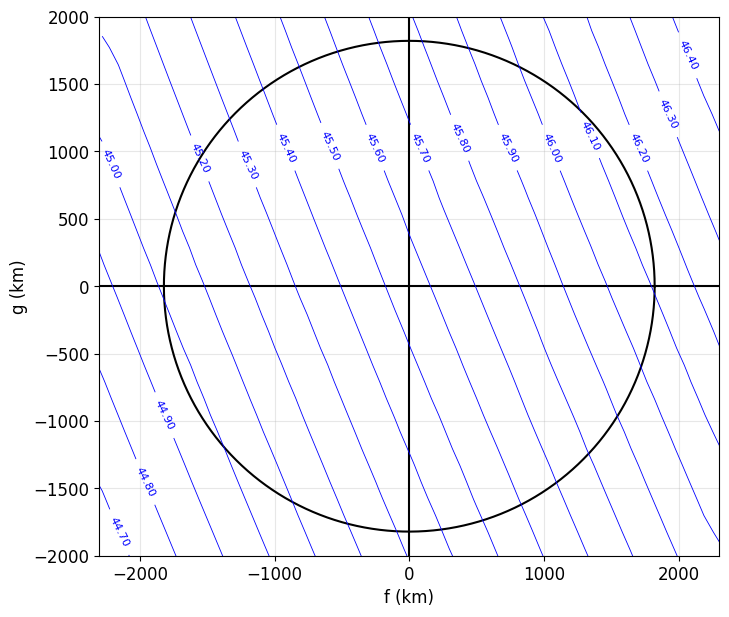

In [76]:
# Atenção: com indexing='xy', os arrays precisam ser transpostos
U = dx_mean.T
V = dy_mean.T
N = count.T

U_jup = dx_mean_jup.T
V_jup = dy_mean_jup.T
N_jup = count_jup.T

U_sun = dx_mean_sun.T
V_sun = dy_mean_sun.T
N_sun = count_sun.T

magnitude = np.sqrt(U**2 + V**2)
mask_empty = N == 0

magnitude_jup = np.sqrt(U_jup**2 + V_jup**2)
mask_empty_jup = N_jup == 0

magnitude_sun = np.sqrt(U_sun**2 + V_sun**2)
mask_empty_sun = N_sun == 0

# células vazias devem ser mascaradas
U_masked = np.ma.masked_where(mask_empty, U)
V_masked = np.ma.masked_where(mask_empty, V)
magnitude_masked = np.ma.masked_where(mask_empty, magnitude)

U_masked_jup = np.ma.masked_where(mask_empty_jup, U_jup)
V_masked_jup = np.ma.masked_where(mask_empty_jup, V_jup)
magnitude_masked_jup = np.ma.masked_where(mask_empty_jup, magnitude_jup)

U_masked_sun = np.ma.masked_where(mask_empty_sun, U_sun)
V_masked_sun = np.ma.masked_where(mask_empty_sun, V_sun)
magnitude_masked_sun = np.ma.masked_where(mask_empty_sun, magnitude_sun)

fig, ax = plt.subplots(figsize=(8, 7))

plt.axhline(0.0, color='black')
plt.axvline(0.0, color='black')
ang = np.linspace(0,360,1000)*np.pi/180
plt.plot(io_radius*np.cos(ang),io_radius*np.sin(ang), color='black')

# Curvas de nível preenchidas
levels = 20

# contour_fill = ax.contourf(
#     xc,
#     yc,
#     magnitude_masked,
#     levels=levels
# )

# Linhas das curvas de nível
contour_lines = ax.contour(
    xc,
    yc,
    magnitude_masked,
    levels=levels,
    linewidths=0.6,
    colors='blue'
)

# Valores escritos sobre algumas curvas
ax.clabel(
    contour_lines,
    inline=True,
    fontsize=8,
    fmt='%.2f'
)

# contour_lines_jup = ax.contour(
#     xc_jup,
#     yc_jup,
#     magnitude_masked_jup,
#     levels=levels,
#     linewidths=0.6
# )

# # Valores escritos sobre algumas curvas
# ax.clabel(
#     contour_lines_jup,
#     inline=True,
#     fontsize=8,
#     fmt='%.2f'
# )

# contour_lines_sun = ax.contour(
#     xc_sun,
#     yc_sun,
#     magnitude_masked_sun,
#     levels=levels,
#     linewidths=0.6
# )

# # Valores escritos sobre algumas curvas
# ax.clabel(
#     contour_lines_sun,
#     inline=True,
#     fontsize=8,
#     fmt='%.5f'
# )

# plt.streamplot(
#     xc, yc,
#     U_masked, V_masked,
#     density=1.5,
#     color=speed,
#     linewidth=1.0,
#     arrowsize=1.2
# )

#cbar = fig.colorbar(contour_lines, ax=ax)
#cbar.set_label(r'$\delta \hat{k}_P - \delta \hat{k}_E$')

plt.axis('equal')
plt.xlim(-2000,2000)
plt.ylim(-2000,2000)
plt.xlabel('f (km)')
plt.ylabel('g (km)')
plt.grid(alpha=0.3)
plt.savefig('Light_deflection_correction.png', dpi=300, bbox_inches='tight')
plt.show()

In [87]:
times = occ_time + np.linspace(-200,200,401)*u.s

dt = (times - t0)

spice.furnsh(kernel)
# calculates vector Solar System Barycenter -> Geocenter
state = spice.spkpos('399', dt.sec, 'J2000', 'NONE', '0')[0]
barycenter_geocenter = SkyCoord(*state.T * u.km, representation_type='cartesian').cartesian

In [90]:
# vector Solar System Barycenter -> Topocenter
geocenter_observer = obs_center.get_gcrs(obstime=times).cartesian
barycenter_observer = barycenter_geocenter + geocenter_observer

In [95]:
def pos_object(target):
    delt = 0 * u.s
    while True:
        # calculates new time
        tempo = dt - delt
        # calculates vector Solar System Barycenter -> Target
        barycenter_object = spice.spkpos(target, tempo.sec, 'J2000', 'NONE', '0')[0]
        barycenter_object = SkyCoord(*barycenter_object.T * u.km, representation_type='cartesian').cartesian
        # calculates vector Observer -> Target considering light time
        observer_object = barycenter_object - barycenter_observer
        # calculates new light time
        delt = (observer_object.norm() / const.c).decompose()
        # if difference between new and previous light time is smaller than 0.001 sec, then continue.
        if np.all(np.absolute(((dt - tempo) - delt).sec) < 0.001):
            return observer_object

In [99]:
pos_jup = SkyCoord(pos_object(jup_spkid), representation_type='cartesian')
pos_sun = SkyCoord(pos_object(sun_spkid), representation_type='cartesian')
pos_io = SkyCoord(pos_object(io_spkid), representation_type='cartesian')

In [115]:
DE_io = pos_io.cartesian.norm()   # target

f = DE_io*(pos_star.ra - pos_io.spherical.lon)*np.cos(pos_io.spherical.lat)
g = DE_io*(pos_star.dec - pos_io.spherical.lat)
f = f.to(u.km, equivalencies=u.dimensionless_angles())
g = g.to(u.km, equivalencies=u.dimensionless_angles())

vec_rso = - pos_star.cartesian
vec_rao = - pos_jup.cartesian
vec_ras = pos_star.cartesian - pos_jup.cartesian
delta_k_star_jup = delta_kpn(gm=jup_GM, vec_rso=vec_rso, vec_rao=vec_rao, vec_ras=vec_ras)

vec_rso = - pos_star.cartesian
vec_rao = - pos_sun.cartesian
vec_ras = pos_star.cartesian - pos_sun.cartesian
delta_k_star_sun = delta_kpn(gm=sun_GM, vec_rso=vec_rso, vec_rao=vec_rao, vec_ras=vec_ras)

vec_rso = - pos_io.cartesian
vec_rao = - pos_jup.cartesian
vec_ras = pos_io.cartesian - pos_jup.cartesian
delta_k_E_jup = delta_kpn(gm=jup_GM, vec_rso=vec_rso, vec_rao=vec_rao, vec_ras=vec_ras)

vec_rso = - pos_io.cartesian
vec_rao = - pos_sun.cartesian
vec_ras = pos_io.cartesian - pos_sun.cartesian
delta_k_E_sun = delta_kpn(gm=sun_GM, vec_rso=vec_rso, vec_rao=vec_rao, vec_ras=vec_ras)

delta_theta_jup, theta_f_jup, theta_g_jup = calc_kP(gm=jup_GM, pos_A=pos_jup, pos_E=pos_io, delta_k_star = delta_k_star_jup)
delta_theta_sun, theta_f_sun, theta_g_sun = calc_kP(gm=sun_GM, pos_A=pos_sun, pos_E=pos_io, delta_k_star = delta_k_star_sun)

delta_f = DE_io*(theta_f_jup + theta_f_sun)
delta_g = DE_io*(theta_g_jup + theta_g_sun)

delta_f_jup = (DE_io*theta_f_jup).to(u.km, equivalencies=u.dimensionless_angles())
delta_g_jup = (DE_io*theta_g_jup).to(u.km, equivalencies=u.dimensionless_angles())
delta_f_sun = (DE_io*theta_f_sun).to(u.km, equivalencies=u.dimensionless_angles())
delta_g_sun = (DE_io*theta_g_sun).to(u.km, equivalencies=u.dimensionless_angles())

delta_f_P = delta_f.to(u.km, equivalencies=u.dimensionless_angles())
delta_g_P = delta_g.to(u.km, equivalencies=u.dimensionless_angles())

delta_theta_E = (delta_k_star_jup + delta_k_star_sun) - (delta_k_E_jup + delta_k_E_sun)

e_f = SkyCoord(-np.sin(pos_io.spherical.lon), np.cos(pos_io.spherical.lon), 0, representation_type='cartesian')
e_g = SkyCoord(-np.cos(pos_io.spherical.lon)*np.sin(pos_io.spherical.lat),
               -np.sin(pos_io.spherical.lon)*np.sin(pos_io.spherical.lat),
               np.cos(pos_io.spherical.lat), representation_type='cartesian')

delta_f_E = (DE_io*np.sum(delta_theta_E.xyz*e_f.cartesian.xyz, axis=0)).to(u.km)
delta_g_E = (DE_io*np.sum(delta_theta_E.xyz*e_g.cartesian.xyz, axis=0)).to(u.km)

In [116]:
chord_dist = np.sqrt(f**2+g**2)
v = np.unravel_index(chord_dist.argmin(), chord_dist.shape)

In [117]:
times[v]

<Time object: scale='utc' format='iso' value=2021-04-02 10:24:00.000>

In [118]:
dif_rel_f = delta_f_P - delta_f_P[v]
dif_rel_g = delta_g_P - delta_g_P[v]

In [119]:
k = np.where(np.sqrt(f**2 + g**2) < io_radius)

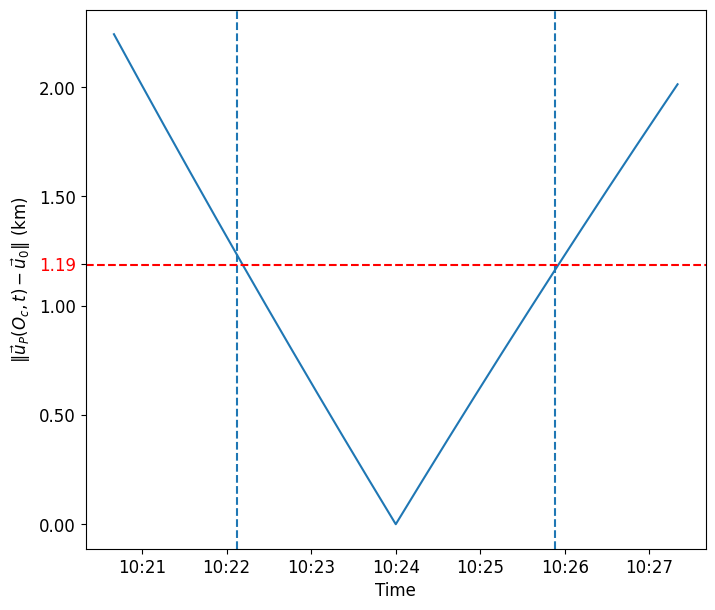

In [141]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize=(8, 7))

plt.plot(times.datetime, np.sqrt(dif_rel_f**2 + dif_rel_g**2))
plt.axvline(times[k].min().datetime, linestyle='--')
plt.axvline(times[k].max().datetime, linestyle='--')
plt.axhline(1.187, color='red', linestyle='--')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ticks = ax.set_yticks([0, 0.5, 1.0, 1.19, 1.5, 2.0])
ticks[3].label1.set_color("red")

plt.xlabel('Time')
plt.ylabel(r'$\|\vec{u}_P(O_c,t) - \vec{u}_0\|$ (km)')
plt.savefig('Residual_deflection_time.png', dpi=300, bbox_inches='tight')